[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke07-velferdsteknologi/01_robotnavigasjon_i_rutenett_med_astar.ipynb)


# 🤖 Robotnavigasjon i 2D-grid med A*

Roboter kan spille en viktig rolle i velferdsteknologi fordi de kan støtte mennesker i oppgaver som er fysisk krevende, repetitive eller tidssensitive. I helse- og omsorgstjenesten kan robotteknologi for eksempel brukes til transport av utstyr, levering av medisiner og prøver, logistikk internt i institusjoner, støtte i rehabilitering og i noen sammenhenger som praktisk hjelp i hjemmet. Potensialet ligger ikke bare i å automatisere arbeid, men i å frigjøre tid, redusere belastning og gjøre tjenestene mer robuste når behovene øker.

Samtidig er det viktig å ha et realistisk blikk på hva roboter faktisk må mestre for å være nyttige. En robot i velferdsteknologi må ikke bare ha en oppgave, men også kunne utføre den på en trygg, forutsigbar og hensiktsmessig måte i et miljø der mennesker beveger seg, der hindringer oppstår, og der konsekvensene av feil kan være betydelige. Derfor er navigasjon et grunnleggende tema: Før en robot kan hjelpe i praksis, må den kunne finne fram.

## Hvorfor er robotnavigasjon viktig?

Robotnavigasjon handler om at et system må kunne bevege seg fra ett sted til et annet uten å kollidere, sette seg fast eller velge uhensiktsmessige ruter. I en helsekontekst kan dette bety å finne veien i en korridor, bevege seg mellom pasientrom, unngå utstyr som står i veien eller tilpasse seg et miljø som stadig endrer seg. Selv om denne notebooken bruker et enkelt 2D-rutenett, representerer det en grunnidé som også ligger bak mer avanserte systemer: Miljøet må representeres, mulige veier må vurderes, og systemet må velge en rute som er effektiv og sikker.

## Hvorfor ser vi på A* her?

A* er en klassisk søkealgoritme for rutefinning som er godt egnet til undervisning fordi den gjør det lett å forstå hvordan en robot kan kombinere det den allerede har beveget seg gjennom med et anslag over hvor langt det er igjen til målet. Dermed blir den et konkret og pedagogisk inngangspunkt til å forstå hvordan roboter kan planlegge bevegelse i strukturerte miljøer. Målet i denne notebooken er ikke å bygge et komplett robotsystem, men å forstå selve navigasjonsproblemet i en enkel form.

## Læringsmål
- forstå hvorfor roboter kan være relevante i velferdsteknologi
- forklare hvorfor navigasjon er en grunnleggende forutsetning for nyttige robotsystemer
- forstå A*-algoritmen og heuristikkens rolle
- implementere rutefinning i et grid med hindringer
- visualisere funnet sti i gridet


### 🔧 Miljøoppsett – fungerer både lokalt og i Google Colab


In [1]:
import sys, os

# Vi sjekker først om notebooken kjører i Google Colab.
# Det er nyttig fordi filstier og arbeidsmappe ofte må håndteres annerledes i Colab enn lokalt.
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")

    # Dersom repoet ikke allerede finnes i Colab-økten, kloner vi det fra GitHub.
    # Dette gjør at notebooken får tilgang til samme mappestruktur som ved lokal kjøring.
    if not os.path.exists('AI-og-helse'):
        import subprocess
        subprocess.check_call(["git", "clone", "https://github.com/arvidl/AI-og-helse.git"])  # type: ignore

    # Når repoet finnes, bytter vi arbeidsmappe slik at relative filstier fungerer som forventet.
    if os.path.exists('AI-og-helse'):
        os.chdir('AI-og-helse')
        print(f"📁 Byttet til mappe: {os.getcwd()}")
else:
    # Ved lokal kjøring antar vi at brukeren allerede står i riktig prosjektmappe.
    print("💻 Kjører i lokalt miljø")

# NumPy bruker vi til å representere gridet som en matrise.
# Matplotlib bruker vi til å visualisere hindringer, startpunkt, mål og funnet rute.
import numpy as np
import matplotlib.pyplot as plt

print("✅ Miljø klart")


💻 Kjører i lokalt miljø
✅ Miljø klart


In [2]:
import heapq

# A* er en klassisk søkealgoritme for rutefinning.
# I dette eksempelet lar vi roboten bevege seg i et 2D-grid med fire mulige retninger:
# opp, ned, venstre og høyre.

def astar(grid: np.ndarray, start: tuple[int, int], goal: tuple[int, int]):
    # Sjekker om en posisjon ligger innenfor gridets grenser.
    # Dette hindrer at algoritmen prøver å gå utenfor kartet.
    def in_bounds(x, y):
        return 0 <= x < grid.shape[0] and 0 <= y < grid.shape[1]

    # Finner gyldige naboceller som roboten kan bevege seg til.
    # Her tillater vi bare 4-naboskap og bare celler med verdi 0,
    # altså celler som ikke er blokkert av hindringer.
    def neighbors(x, y):
        for dx, dy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny) and grid[nx, ny] == 0:
                yield (nx, ny)

    # Manhattan-avstand passer godt når man bare kan gå horisontalt og vertikalt.
    # Den fungerer som en heuristikk: et raskt anslag over hvor langt det er igjen til målet.
    def manhattan(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    # open_heap er prioritetskøen over noder som skal utforskes videre.
    # A* velger alltid noden med lavest estimert total kostnad først.
    open_heap = [(0, start)]

    # g lagrer den beste kjente kostnaden fra start til hver posisjon.
    g = {start: 0}

    # came_from brukes til å rekonstruere ruten når vi har nådd målet.
    # For hver celle husker vi hvilken celle vi kom fra.
    came_from = {start: None}

    # Så lenge det finnes kandidater å utforske, fortsetter søket.
    while open_heap:
        _, cur = heapq.heappop(open_heap)

        # Hvis vi har nådd målet, rekonstruerer vi hele stien baklengs.
        if cur == goal:
            path = []
            while cur is not None:
                path.append(cur)
                cur = came_from[cur]
            return path[::-1]

        # Vi vurderer alle lovlige naboer til den nåværende cellen.
        for nb in neighbors(*cur):
            # tentative er kostnaden for å nå naboen via den nåværende cellen.
            # I dette enkle eksempelet koster hvert steg 1.
            tentative = g[tuple(cur)] + 1

            # Hvis vi har funnet en bedre vei til naboen enn tidligere,
            # oppdaterer vi både kostnad og hvor vi kom fra.
            if tentative < g.get(tuple(nb), float('inf')):
                g[tuple(nb)] = tentative
                came_from[tuple(nb)] = tuple(cur)

                # f = faktisk kostnad så langt + heuristisk anslag til mål.
                # Det er denne verdien A* bruker for å prioritere hva som utforskes videre.
                f = tentative + manhattan(nb, goal)
                heapq.heappush(open_heap, (f, tuple(nb)))

    # Hvis køen tømmes uten at målet nås, finnes det ingen gyldig rute.
    return None


Fant sti: True


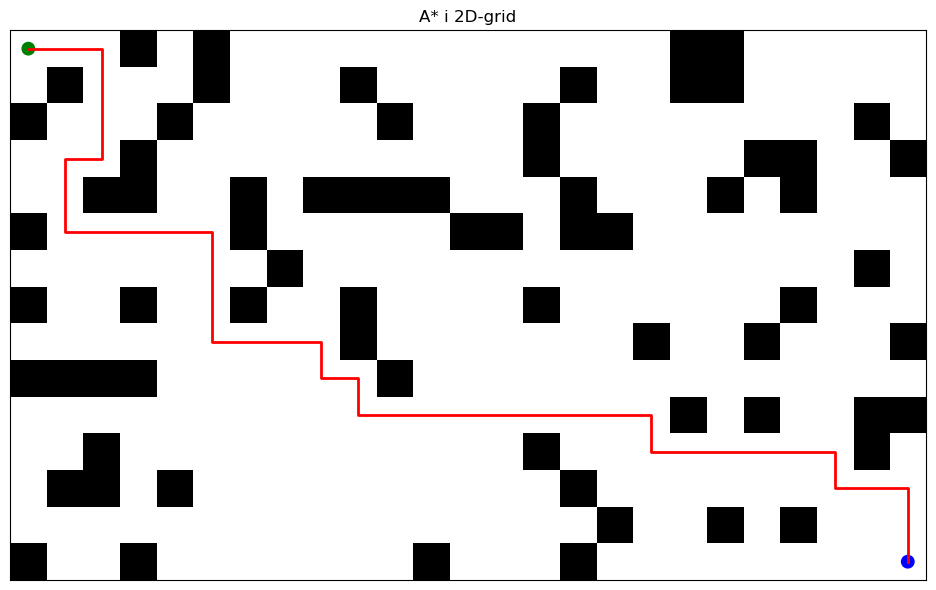

In [3]:
# Vi lager et enkelt, syntetisk kart som roboten skal navigere i.
# Gridet består av frie celler (0) og hindringer (1).
np.random.seed(0)
H, W = 15, 25
grid = np.zeros((H, W), dtype=int)

# Vi legger inn tilfeldige hindringer for å simulere at noen områder er blokkert.
# Dette er en enkel måte å lage et miljø der roboten ikke kan gå rett fram hele tiden.
for _ in range(80):
    grid[np.random.randint(0, H), np.random.randint(0, W)] = 1

# Vi definerer start- og målposisjon.
# Start er øverst til venstre, og mål er nederst til høyre.
start = (0, 0)
goal = (H - 1, W - 1)

# Selv om hindringene er tilfeldig generert, sørger vi for at start og mål alltid er frie.
# Uten dette kunne vi risikert at oppgaven var umulig allerede før søket starter.
grid[start] = 0
grid[goal] = 0

# Vi kjører A* for å finne en sti fra start til mål.
# Hvis algoritmen lykkes, returneres en liste med koordinater som utgjør ruten.
path = astar(grid, start, goal)
print("Fant sti:", path is not None)

# Deretter visualiserer vi miljøet og ruten.
# 'gray_r' gjør at frie områder og hindringer blir tydelige i figuren.
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(grid, cmap='gray_r')

# Hvis en rute finnes, tegner vi den opp som en rød linje gjennom gridet.
if path:
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    ax.plot(xs, ys, color='red', linewidth=2)

# Vi markerer start og mål med ulike farger for å gjøre navigasjonen lettere å lese visuelt.
ax.scatter([start[1], goal[1]], [start[0], goal[0]], c=['green', 'blue'], s=80)
ax.set_title('A* i 2D-grid')

# Vi skjuler akseverdier fordi fokus her er selve rutefinningen, ikke eksakte koordinattall.
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()


## Hva viser dette eksemplet?

Dette eksemplet viser i en forenklet form hva et navigasjonssystem må gjøre: representere et miljø, identifisere hvilke områder som kan passeres, og finne en rute fra start til mål uten å kollidere med hindringer. Selv om gridet er langt enklere enn et virkelig sykehjem, sykehus eller hjemmemiljø, illustrerer det et viktig prinsipp: En robot må hele tiden koble sammen informasjon om omgivelsene med en strategi for trygg og effektiv bevegelse.

I praksis er dette relevant fordi navigasjon ikke bare handler om å komme fram, men om å komme fram på en måte som er hensiktsmessig i et miljø med mennesker. En robot som skal levere utstyr eller støtte logistikk i en helsetjeneste, må kunne unngå blokkeringer, velge ruter som ikke skaper unødig risiko, og fungere stabilt også når omgivelsene endrer seg. Derfor er rutefinning en grunnleggende byggestein i mer avansert velferdsteknologi.

<details>
<summary><strong>Refleksjon</strong></summary>

- Hvordan påvirker heuristikk, for eksempel Manhattan versus Euclidean, hvor raskt algoritmen finner en løsning?
- Hva skjer dersom gridet er så tett av hindringer at ingen rute finnes, og hvordan bør et robotsystem håndtere en slik situasjon?
- Hvordan ville du utvidet modellen dersom noen områder var mulig å passere, men mindre ønskelige enn andre?
- Hvilke ekstra hensyn måtte vært med dersom roboten skulle navigere i et miljø med mennesker, ikke bare statiske hindringer?
- På hvilke måter er dette grid-eksempelet nyttig pedagogisk, og hvilke viktige sider ved ekte robotnavigasjon fanger det ikke opp?

</details>


## Oppsummering

I denne notebooken har vi brukt A* for å illustrere hvordan robotnavigasjon kan forstås som et problem om representasjon, søk og valg av rute. Poenget er ikke at et enkelt 2D-grid er nok for reelle robotsystemer, men at det gir en tydelig modell for å forstå et grunnleggende problem i velferdsteknologi.

Videre i uke 07 går vi fra robotens bevegelse i rommet til hvordan teknologiske systemer også må tolke sensordata, forstå aktivitet og støtte beslutninger i helse- og omsorgssituasjoner.
